# Common Mind Survey - Exploratory Data Analysis

This notebook performs initial EDA on the Typeform survey export data.

**Setup:** Run the cells below to install packages and connect to your data.

In [1]:
# Install required packages (run once)
!pip install -q pandas numpy matplotlib seaborn plotly openpyxl openai

In [2]:
# Mount Google Drive to access your data files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Plot settings
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Data

**Option A:** Load from Google Drive (recommended)  
**Option B:** Upload file directly to Colab

In [4]:
# OPTION A: Load from Google Drive
# Update this path to match where you saved your Typeform export in Drive
DATA_PATH = '/content/drive/MyDrive/_Client_Files/CommonMind/ai-driven-search-report/'

# List files in the folder
import os
if os.path.exists(DATA_PATH):
    print('Files in folder:')
    for f in os.listdir(DATA_PATH):
        print(f'  - {f}')
else:
    print(f'Folder not found: {DATA_PATH}')
    print('Create this folder in Drive and upload your Typeform export, or update the path.')

Files in folder:
  - responses-cBLhVOUI-01KG5YNCSM9KM8SYBNTTQ98AC7-XPX692KPUA2130X3ZAN5TKT4.csv


In [5]:
# OPTION B: Upload file directly (alternative to Drive)
# Uncomment to use:

# from google.colab import files
# uploaded = files.upload()  # This will prompt you to select a file
# filename = list(uploaded.keys())[0]
# df = pd.read_csv(filename)  # or pd.read_excel(filename)

In [6]:
# Load the survey data from Drive
# Update the filename to match your Typeform export

FILENAME = 'responses-cBLhVOUI-01KG5YNCSM9KM8SYBNTTQ98AC7-XPX692KPUA2130X3ZAN5TKT4.csv'  # <-- UPDATE THIS

filepath = DATA_PATH + FILENAME
if FILENAME.endswith('.csv'):
    df = pd.read_csv(filepath)
else:
    df = pd.read_excel(filepath)

print(f'Loaded {len(df)} responses')
df.head()

Loaded 166 responses


,#,What is your primary email address for us to contact you?,What industry is your company in?,Other,How many employees does your company have?,"Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?",*How important is it* for your brand to appear in _AI search/LLMs_?,"*How important is it* for your brand to maintain visibility in _traditional search engines_ (Google, Bing, etc)?",*How confident do you feel* that your brand will maintain visibility as AI search & LLMs evolve?,How mature is your brand’s strategy for AI visibility and zero-click results?,More branded searches in Google,More traffic directly from LLMs,More leads or sales,Better quality leads,Higher trust,Other.1,"Compared to last year, your organic traffic from Google is:","In your Google Analytics 4 (GA4) Reports (or other analytics platform), *are you able to easily see how much traffic is referred by LLMs such as ChatGPT?*",Roughly how much of your traffic comes from AI referrals?,No analytics setup for this,Hard to detect referrer,Low volumes so far,Leadership hasn’t prioritized it,Don’t know how to track this,Other.2,Pricing pages,How-To/What Is content,Comparison pages (Your brand vs competitor),“Best of” lists,"Problems (""what can go wrong"")","Reviews, testimonials & case studies",Thought leadership,Original research,Other.3,Do you currently publish pricing on your website?,Do you have structured data or schema markup implemented on your website?,Executive summaries or TL;DR sections,Comparison tables,Author bios with credentials,None of the above,Other.4,G2,Capterra,TrustRadius,Software Advice,Clutch,TrustPilot,Google,Yelp,None of the above.1,Not sure,Other.5,Backlinks (traditional link-building),PR / Earned media,"Reviews (G2, Google Reviews, etc)",Social media platforms,"Video platforms (YouTube, etc)",Reddit / other communities,Guest posting,Podcast guest appearances,None of the above.2,Not sure.1,Other.6,Backlinks (traditional link-building).1,PR / earned media,"Reviews (G2, Google Reviews, etc).1",Social media platforms.1,"Video platforms (YouTube, etc).1",Reddit / other communities.1,Guest posting.1,Podcast guest appearances.1,None of the above.3,Not sure.2,Other.7,"AI SEO/GEO graders & visibility tools (e.g. Jarts, AI Trust Signals, Visto, etc.)","SEO/SEM tools (e.g. Semrush, Ahrefs, etc.)",Manual spot-checks,“How did you hear about us?” field,Analytics tagging,Not sure.3,Not measuring yet,"How frequently do you refresh or update existing content (blogs, articles, videos, etc.)?",Subject matter experts’ time,Analytics/measurement gaps,Marketing/content team bandwidth,Leadership buy-in,Budget constraints,Competing priorities,Unsure how to adapt strategy,None,Other.8,Pricing pages.1,Comparison pages,“Best of” lists.1,Problems / “what can go wrong”,Reviews & case studies,How-To / What-Is content,Thought leadership.1,Original research.1,Not sure.4,None of the above.4,Other.9,Publish more video content,Increase activity on social,Increase activity on Reddit/Quora,Add/expand schema on website,Change writing style and/or page structure to accommodate LLMs,Not sure.5,None of the above.5,Other.10,"*How confident are you that your team can publish enough content to maintain or grow visibility* across traditional search (Google) and/or AI search platforms (ChatGPT, Perplexity, etc) in 2026?",What is your *biggest fear about AI-driven search for your brand?*,"What’s the #1 experiment or tactic you’ve tried (or want to try) to improve AI/AEO visibility? \n\nWhat, if any, results are you seeing from it?",What question do you hope this report will answer for leaders like you?,Your email address (so we can send you the report and/or request a quote):,Your first name (so we know who we're sending it to):,utm_source,utm_medium,utm_campaign,utm_term,utm_content,Response Type,Start Date (UTC),Stage Date (UTC),Submit Date (UTC),Network ID,Tags,Ending
0,lzkzj7np8li35bz2mmlzkzi4fjbioxvv,quinn.mackay@h

## 2. Data Overview

In [7]:
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'\nColumn names:\n')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

Dataset shape: 166 rows, 128 columns

Column names:

  1. #
  2. What is your primary email address for us to contact you?
  3. What industry is your company in?
  4. Other
  5. How many employees does your company have?
  6. Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?
  7. *How important is it* for your brand to appear in _AI search/LLMs_?
  8. *How important is it* for your brand to maintain visibility in _traditional search engines_ (Google, Bing, etc)?
  9. *How confident do you feel* that your brand will maintain visibility as AI search & LLMs evolve?
  10. How mature is your brand’s strategy for AI visibility and zero-click results?
  11. More branded searches in Google
  12. More traffic directly from LLMs
  13. More leads or sales
  14. Better quality leads
  15. Higher trust
  16. Other.1
  17. Compared to last year, your organic traffic from Google is:
  18. In your Google Analytics 4 (GA4) Report

In [8]:
# Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Columns: 128 entries, # to Ending
dtypes: float64(3), int64(4), object(121)
memory usage: 166.1+ KB


In [9]:
# Summary statistics
df.describe(include='all')

,#,What is your primary email address for us to contact you?,What industry is your company in?,Other,How many employees does your company have?,"Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?",*How important is it* for your brand to appear in _AI search/LLMs_?,"*How important is it* for your brand to maintain visibility in _traditional search engines_ (Google, Bing, etc)?",*How confident do you feel* that your brand will maintain visibility as AI search & LLMs evolve?,How mature is your brand’s strategy for AI visibility and zero-click results?,More branded searches in Google,More traffic directly from LLMs,More leads or sales,Better quality leads,Higher trust,Other.1,"Compared to last year, your organic traffic from Google is:","In your Google Analytics 4 (GA4) Reports (or other analytics platform), *are you able to easily see how much traffic is referred by LLMs such as ChatGPT?*",Roughly how much of your traffic comes from AI referrals?,No analytics setup for this,Hard to detect referrer,Low volumes so far,Leadership hasn’t prioritized it,Don’t know how to track this,Other.2,Pricing pages,How-To/What Is content,Comparison pages (Your brand vs competitor),“Best of” lists,"Problems (""what can go wrong"")","Reviews, testimonials & case studies",Thought leadership,Original research,Other.3,Do you currently publish pricing on your website?,Do you have structured data or schema markup implemented on your website?,Executive summaries or TL;DR sections,Comparison tables,Author bios with credentials,None of the above,Other.4,G2,Capterra,TrustRadius,Software Advice,Clutch,TrustPilot,Google,Yelp,None of the above.1,Not sure,Other.5,Backlinks (traditional link-building),PR / Earned media,"Reviews (G2, Google Reviews, etc)",Social media platforms,"Video platforms (YouTube, etc)",Reddit / other communities,Guest posting,Podcast guest appearances,None of the above.2,Not sure.1,Other.6,Backlinks (traditional link-building).1,PR / earned media,"Reviews (G2, Google Reviews, etc).1",Social media platforms.1,"Video platforms (YouTube, etc).1",Reddit / other communities.1,Guest posting.1,Podcast guest appearances.1,None of the above.3,Not sure.2,Other.7,"AI SEO/GEO graders & visibility tools (e.g. Jarts, AI Trust Signals, Visto, etc.)","SEO/SEM tools (e.g. Semrush, Ahrefs, etc.)",Manual spot-checks,“How did you hear about us?” field,Analytics tagging,Not sure.3,Not measuring yet,"How frequently do you refresh or update existing content (blogs, articles, videos, etc.)?",Subject matter experts’ time,Analytics/measurement gaps,Marketing/content team bandwidth,Leadership buy-in,Budget constraints,Competing priorities,Unsure how to adapt strategy,None,Other.8,Pricing pages.1,Comparison pages,“Best of” lists.1,Problems / “what can go wrong”,Reviews & case studies,How-To / What-Is content,Thought leadership.1,Original research.1,Not sure.4,None of the above.4,Other.9,Publish more video content,Increase activity on social,Increase activity on Reddit/Quora,Add/expand schema on website,Change writing style and/or page structure to accommodate LLMs,Not sure.5,None of the above.5,Other.10,"*How confident are you that your team can publish enough content to maintain or grow visibility* across traditional search (Google) and/or AI search platforms (ChatGPT, Perplexity, etc) in 2026?",What is your *biggest fear about AI-driven search for your brand?*,"What’s the #1 experiment or tactic you’ve tried (or want to try) to improve AI/AEO visibility? \n\nWhat, if any, results are you seeing from it?",What question do you hope this report will answer for leaders like you?,Your email address (so we can send you the report and/or request a quote):,Your first name (so we know who we're sending it to):,utm_source,utm_medium,utm_campaign,utm_term,utm_content,Response Type,Start Date (UTC),Stage Date (UTC),Submit Date (UTC),Network ID,Tags,Ending
count,166,163,151,15,166,166,166.000000,166.00000

In [10]:
df.describe()

,*How important is it* for your brand to appear in _AI search/LLMs_?,"*How important is it* for your brand to maintain visibility in _traditional search engines_ (Google, Bing, etc)?",*How confident do you feel* that your brand will maintain visibility as AI search & LLMs evolve?,None,"*How confident are you that your team can publish enough content to maintain or grow visibility* across traditional search (Google) and/or AI search platforms (ChatGPT, Perplexity, etc) in 2026?",utm_content,Tags
count,166.000000,166.000000,166.000000,0.0,166.000000,0.0,0.0
mean,4.506024,4.590361,3.608434,NaN,3.512048,NaN,NaN
std,0.736470,0.722557,1.007692,NaN,1.115934,NaN,NaN
min,2.000000,2.000000,1.000000,NaN,1.000000,NaN,NaN
25%,4.000000,4.000000,3.000000,NaN,3.000000,NaN,NaN
50%,5.000000,5.000000,4.000000,NaN,4.000000,NaN,NaN
75%,5.000000,5.000000,4.000000,NaN,4.000000,NaN,NaN
max,5.000000,5.000000,5.000000,NaN,5.000000,NaN,NaN


In [11]:
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 128 columns):
 #    Column                                                                                                                                                                                              Non-Null Count  Dtype  
---   ------                                                                                                                                                                                              --------------  -----  
 0    #                                                                                                                                                                                                   166 non-null    object 
 1    What is your primary email address for us to contact you?                                                                                                                                           163 non-null  

In [12]:
df.info(max_cols=200)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 128 columns):
 #    Column                                                                                                                                                                                              Non-Null Count  Dtype  
---   ------                                                                                                                                                                                              --------------  -----  
 0    #                                                                                                                                                                                                   166 non-null    object 
 1    What is your primary email address for us to contact you?                                                                                                                                           163 non-null  

In [13]:
pd.set_option('display.width', None)
df.info(verbose=True, show_counts=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 128 columns):
 #    Column                                                                                                                                                                                              Non-Null Count  Dtype  
---   ------                                                                                                                                                                                              --------------  -----  
 0    #                                                                                                                                                                                                   166 non-null    object 
 1    What is your primary email address for us to contact you?                                                                                                                                           163 non-null  

In [14]:
df.dtypes

,0
#,object
What is your primary email address for us to contact you?,object
What industry is your company in?,object
Other,object
How many employees does your company have?,object
...,...
Stage Date (UTC),object
Submit Date (UTC),object
Network ID,object
Tags,float64


In [15]:
df.nunique()

,0
#,166
What is your primary email address for us to contact you?,160
What industry is your company in?,10
Other,15
How many employees does your company have?,6
...,...
Stage Date (UTC),1
Submit Date (UTC),165
Network ID,163
Tags,0


In [16]:
pd.set_option('display.max_rows', None)
df.nunique()


,0
#,166
What is your primary email address for us to contact you?,160
What industry is your company in?,10
Other,15
How many employees does your company have?,6
"Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?",2
*How important is it* for your brand to appear in _AI search/LLMs_?,4
"*How important is it* for your brand to maintain visibility in _traditional search engines_ (Google, Bing, etc)?",4
*How confident do you feel* that your brand will maintain visibility as AI search & LLMs evolve?,5
How mature is your brand’s strategy for AI visibility and zero-click results?,5


## 3. Missing Data Analysis

In [17]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=False)

,Missing,Percent
utm_content,166,100.0
Tags,166,100.0
None,166,100.0
None of the above.4,165,99.4
Stage Date (UTC),165,99.4
Other.1,164,98.8
None of the above.5,164,98.8
Other.10,164,98.8
Other.8,163,98.2
Other.6,162,97.6


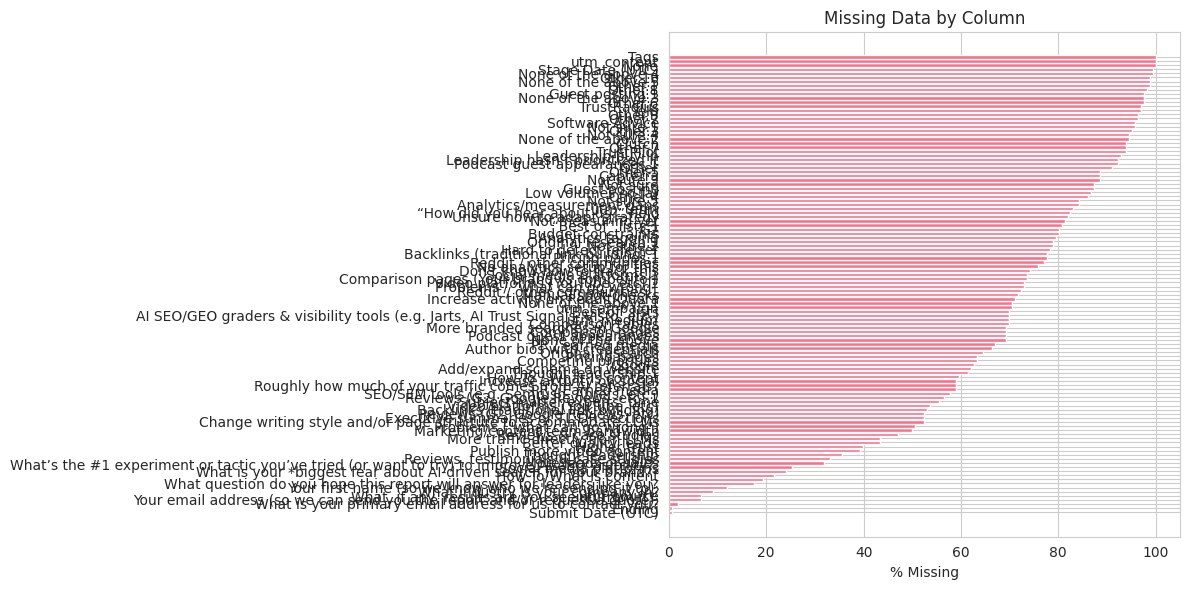

In [18]:
# Visualize missing data
if missing_df['Missing'].sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_data = missing_df[missing_df['Missing'] > 0].sort_values('Percent', ascending=True)
    plt.barh(range(len(missing_data)), missing_data['Percent'])
    plt.yticks(range(len(missing_data)), missing_data.index)
    plt.xlabel('% Missing')
    plt.title('Missing Data by Column')
    plt.tight_layout()
    plt.show()
else:
    print('No missing data!')

## 4. Response Distributions

In [19]:
# Identify categorical columns (for visualization)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f'  - {col}: {unique_count} unique values')

Categorical columns (121):
  - #: 166 unique values
  - What is your primary email address for us to contact you?: 160 unique values
  - What industry is your company in?: 10 unique values
  - Other: 15 unique values
  - How many employees does your company have?: 6 unique values
  - Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?: 2 unique values
  - How mature is your brand’s strategy for AI visibility and zero-click results?: 5 unique values
  - More branded searches in Google: 1 unique values
  - More traffic directly from LLMs: 1 unique values
  - More leads or sales: 1 unique values
  - Better quality leads: 1 unique values
  - Higher trust: 1 unique values
  - Other.1: 2 unique values
  - Compared to last year, your organic traffic from Google is:: 8 unique values
  - In your Google Analytics 4 (GA4) Reports (or other analytics platform), *are you able to easily see how much traffic is referred by LLMs s

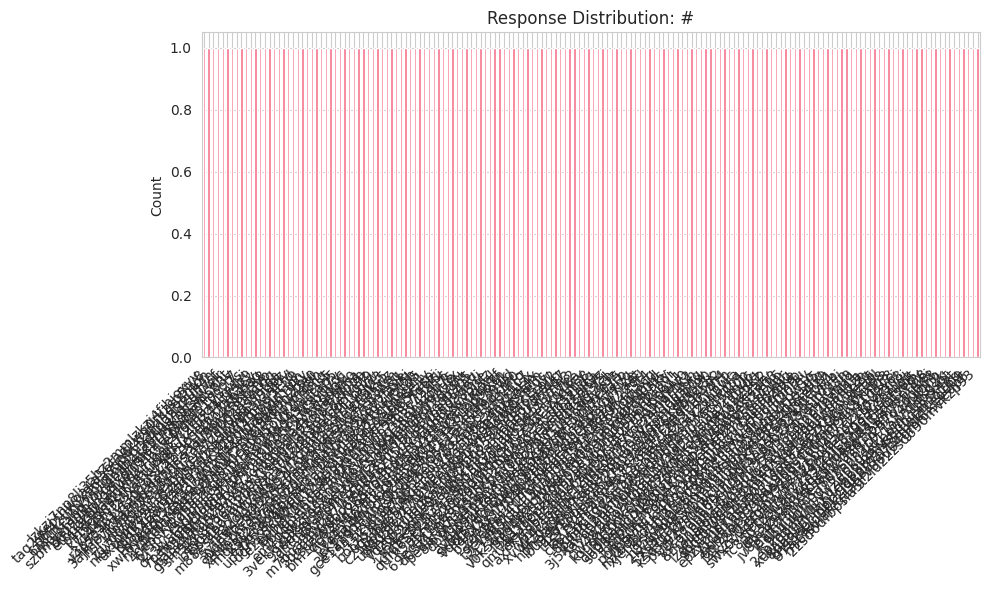

In [20]:
# Visualize a categorical column
# Update COLUMN_NAME to explore different questions

COLUMN_NAME = categorical_cols[0] if categorical_cols else None  # <-- UPDATE THIS

if COLUMN_NAME:
    fig, ax = plt.subplots(figsize=(10, 6))
    df[COLUMN_NAME].value_counts().plot(kind='bar', ax=ax)
    plt.title(f'Response Distribution: {COLUMN_NAME}')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 5. AI-Powered Analysis (Optional)

Use OpenAI to analyze open-ended text responses.

In [21]:
# Set your OpenAI API key
import os
from getpass import getpass

# This will prompt you to enter your API key securely
os.environ['OPENAI_API_KEY'] = getpass('Enter your OpenAI API key: ')

Enter your OpenAI API key: ··········


In [22]:
from openai import OpenAI

client = OpenAI()

def analyze_responses(responses, question=""):
    """Analyze open-ended survey responses using AI."""
    responses_text = "\n---\n".join(responses[:50])  # Limit to 50 for API costs

    prompt = f"""Analyze these survey responses{f' to the question: {question}' if question else ''}.

Provide:
1. Key themes and patterns
2. Common sentiments
3. Notable insights

Responses:
{responses_text}"""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )
    return response.choices[0].message.content

In [23]:
# Analyze a text column
# Update TEXT_COLUMN to the column containing open-ended responses

TEXT_COLUMN = None  # <-- UPDATE THIS (e.g., 'What feedback do you have?')

if TEXT_COLUMN and TEXT_COLUMN in df.columns:
    text_responses = df[TEXT_COLUMN].dropna().tolist()
    print(f'Analyzing {len(text_responses)} responses...\n')
    analysis = analyze_responses(text_responses, question=TEXT_COLUMN)
    print(analysis)
else:
    print('Set TEXT_COLUMN to a column name containing open-ended responses')

Set TEXT_COLUMN to a column name containing open-ended responses


## 6. Next Steps

- [ ] Clean and preprocess the data
- [ ] Deep-dive into specific survey questions
- [ ] Cross-tabulate responses
- [ ] Generate insights report

# Data Clean Section

In [24]:
import pandas as pd
import re

# Load the data
df = pd.read_csv('/content/drive/MyDrive/_Client_Files/CommonMind/ai-driven-search-report/responses-cBLhVOUI-01KG5YNCSM9KM8SYBNTTQ98AC7-XPX692KPUA2130X3ZAN5TKT4.csv')

# Quick look at shape
print(f"Loaded {len(df)} responses, {len(df.columns)} columns")


Loaded 166 responses, 128 columns


In [25]:
# These are the Typeform metadata columns at the end
metadata_cols = ['#', 'utm_source', 'utm_medium', 'utm_campaign', 'utm_term',
                 'utm_content', 'Response Type', 'Start Date (UTC)',
                 'Stage Date (UTC)', 'Submit Date (UTC)', 'Network ID', 'Tags', 'Ending']

# Split into metadata and survey responses
meta_df = df[[c for c in metadata_cols if c in df.columns]].copy()
survey_df = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors='ignore').copy()

print(f"Survey columns: {len(survey_df.columns)}")
print(f"Metadata columns: {len(meta_df.columns)}")


Survey columns: 115
Metadata columns: 13


In [26]:
# Multi-select questions have repeated values across adjacent columns
# This function detects and groups them

def identify_multiselect_groups(df):
    """Identify groups of columns that belong to multi-select questions."""
    groups = []
    current_group = []

    cols = list(df.columns)

    for i, col in enumerate(cols):
        # Check if this column name matches an option pattern
        # (typically short phrases that appear as values in other responses)
        unique_vals = df[col].dropna().unique()

        # If column has only 1-2 unique values and one matches the column name, it's likely a multi-select option
        is_option_col = (len(unique_vals) <= 2 and
                        any(str(col) in str(v) for v in unique_vals if pd.notna(v)))

        # Check if this looks like an "Other" field following options
        is_other = col == 'Other' or col.startswith('Other')

        if is_option_col:
            current_group.append(col)
        elif current_group:
            # End of a group
            if len(current_group) > 1:
                groups.append(current_group.copy())
            current_group = []

    # Don't forget last group
    if len(current_group) > 1:
        groups.append(current_group)

    return groups

multiselect_groups = identify_multiselect_groups(survey_df)
print(f"Found {len(multiselect_groups)} multi-select question groups:")
for i, group in enumerate(multiselect_groups):
    print(f"\n  Group {i+1} ({len(group)} options):")
    for opt in group[:5]:  # Show first 5
        print(f"    - {opt}")
    if len(group) > 5:
        print(f"    ... and {len(group)-5} more")


Found 10 multi-select question groups:

  Group 1 (5 options):
    - More branded searches in Google
    - More traffic directly from LLMs
    - More leads or sales
    - Better quality leads
    - Higher trust

  Group 2 (5 options):
    - No analytics setup for this
    - Hard to detect referrer
    - Low volumes so far
    - Leadership hasn’t prioritized it
    - Don’t know how to track this

  Group 3 (8 options):
    - Pricing pages
    - How-To/What Is content
    - Comparison pages (Your brand vs competitor)
    - “Best of” lists
    - Problems ("what can go wrong")
    ... and 3 more

  Group 4 (4 options):
    - Executive summaries or TL;DR sections
    - Comparison tables
    - Author bios with credentials
    - None of the above

  Group 5 (8 options):
    - G2
    - Capterra
    - TrustRadius
    - Software Advice
    - Clutch
    ... and 3 more

  Group 6 (8 options):
    - Backlinks (traditional link-building)
    - PR / Earned media
    - Reviews (G2, Google Reviews, etc

In [27]:
def consolidate_multiselect(df, groups):
    """Combine multi-select option columns into single list columns."""
    df_clean = df.copy()

    for group in groups:
        # Create a name for the consolidated column (use first option or find common pattern)
        group_name = f"MULTI: {group[0][:50]}..." if len(group[0]) > 50 else f"MULTI: {group[0]}"

        # For each row, collect which options were selected
        def get_selections(row):
            selected = []
            for col in group:
                if pd.notna(row[col]) and str(row[col]).strip():
                    selected.append(col)
            return selected if selected else None

        df_clean[group_name] = df_clean.apply(get_selections, axis=1)

        # Drop the original option columns
        df_clean = df_clean.drop(columns=group)

    return df_clean

survey_clean = consolidate_multiselect(survey_df, multiselect_groups)
print(f"Reduced from {len(survey_df.columns)} to {len(survey_clean.columns)} columns")


Reduced from 115 to 67 columns


In [28]:
def clean_column_name(col):
    """Remove Typeform formatting from column names."""
    # Remove markdown-style formatting
    col = re.sub(r'\*([^*]+)\*', r'\1', col)  # *bold*
    col = re.sub(r'_([^_]+)_', r'\1', col)    # _italic_
    col = col.strip()
    return col

survey_clean.columns = [clean_column_name(c) for c in survey_clean.columns]
print("Cleaned column names:")
for col in survey_clean.columns:
    print(f"  - {col}")


Cleaned column names:
  - What is your primary email address for us to contact you?
  - What industry is your company in?
  - Other
  - How many employees does your company have?
  - Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?
  - How important is it for your brand to appear in AI search/LLMs?
  - How important is it for your brand to maintain visibility in traditional search engines (Google, Bing, etc)?
  - How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?
  - How mature is your brand’s strategy for AI visibility and zero-click results?
  - Other.1
  - Compared to last year, your organic traffic from Google is:
  - In your Google Analytics 4 (GA4) Reports (or other analytics platform), are you able to easily see how much traffic is referred by LLMs such as ChatGPT?
  - Roughly how much of your traffic comes from AI referrals?
  - Other.2
  - Other.3
  - Do you c

In [29]:
# Final cleaned DataFrame
print(f"\nFinal shape: {survey_clean.shape}")
survey_clean.head(3)



Final shape: (166, 67)


,What is your primary email address for us to contact you?,What industry is your company in?,Other,How many employees does your company have?,"Have you changed your approach to content to help your brand appear in AI search (ChatGPT, LLMs, Google AI Overview, etc.)?",How important is it for your brand to appear in AI search/LLMs?,"How important is it for your brand to maintain visibility in traditional search engines (Google, Bing, etc)?",How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?,How mature is your brand’s strategy for AI visibility and zero-click results?,Other.1,"Compared to last year, your organic traffic from Google is:","In your Google Analytics 4 (GA4) Reports (or other analytics platform), are you able to easily see how much traffic is referred by LLMs such as ChatGPT?",Roughly how much of your traffic comes from AI referrals?,Other.2,Other.3,Do you currently publish pricing on your website?,Do you have structured data or schema markup implemented on your website?,Other.4,None of the above.1,Not sure,Other.5,None of the above.2,Not sure.1,Other.6,Backlinks (traditional link-building).1,PR / earned media,"Reviews (G2, Google Reviews, etc).1",Social media platforms.1,"Video platforms (YouTube, etc).1",Reddit / other communities.1,Guest posting.1,Podcast guest appearances.1,None of the above.3,Not sure.2,Other.7,Not sure.3,Not measuring yet,"How frequently do you refresh or update existing content (blogs, articles, videos, etc.)?",None,Other.8,Pricing pages.1,Comparison pages,“Best of” lists.1,Thought leadership.1,Original research.1,Not sure.4,None of the above.4,Other.9,Not sure.5,None of the above.5,Other.10,"How confident are you that your team can publish enough content to maintain or grow visibility across traditional search (Google) and/or AI search platforms (ChatGPT, Perplexity, etc) in 2026?",What is your biggest fear about AI-driven search for your brand?,"What’s the #1 experiment or tactic you’ve tried (or want to try) to improve AI/AEO visibility? \n\nWhat, if any, results are you seeing from it?",What question do you hope this report will answer for leaders like you?,Your email address (so we can send you the report and/or request a quote):,Your first name (so we know who we're sending it to):,MULTI: More branded searches in Google,MULTI: No analytics setup for this,MULTI: Pricing pages,MULTI: Executive summaries or TL;DR sections,MULTI: G2,MULTI: Backlinks (traditional link-building),"MULTI: AI SEO/GEO graders & visibility tools (e.g. Jarts,...",MULTI: Subject matter experts’ time,MULTI: Problems / “what can go wrong”,MULTI: Publish more video content
0,quinn.mackay@hammertech.com,B2B SaaS,NaN,51-200,Yes,4,4,4,"Emerging strategy, some efforts defined",NaN,*🟢 Up 5–20%*,Yes,1–5%,NaN,NaN,No,Yes,"Clear semantic structure, schema markups, Q&A content (being added to most blogs and on new page...",None of the above,NaN,"We did, but not currently",None of the above,NaN,NaN,NaN,PR / earned media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not sure,NaN,NaN,NaN,Rarely/Never,NaN,NaN,NaN,Comparison pages,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,"Keeping up, and showing that we are keeping up.","Adding Schema mark-ups to our pages, and adding FAQ sections to our pages and blogs. I also crea...",A simple approach to be successful moving forward.,quinn.mackay@hammertech.com,Quinn,"[More traffic directly from LLMs, More leads or sales, Higher trust]",None,"[Pricing pages, How-To/What Is content, Problems (""what can go wrong""), Reviews, testimonials & ...",None,None,None,"[SEO/SEM tools (e.g. Semrush, Ahrefs, etc.)]","[Subject matter experts’ time, Marketing/content team bandwidth, Budget constraints]","[Problems / “what can go wrong”, How-To / What-Is content]","[Publish more video content, Add/expand schema on website, Change writing style and/or page stru..."
1,praj@fieldwire.com,B2B SaaS,NaN,"201-1,000",Yes,5,5,4,"Emerging strategy, some efforts defined",NaN,*🟢 Up 5–20%*,No,NaN,NaN,NaN

In [30]:
# First, understand what's missing
print("=== MISSING DATA ANALYSIS ===\n")
missing = survey_clean.isnull().sum()
missing_pct = (missing / len(survey_clean) * 100).round(1)
missing_report = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_report = missing_report[missing_report['Missing'] > 0].sort_values('Percent', ascending=False)
print(missing_report)

# For multi-select columns, NaN means "none selected" - that's valid data, not missing
# For opinion scales, NaN might mean skipped - decide how to handle

# Create a copy for analysis
df = survey_clean.copy()

# For numeric opinion scales, we can leave NaN or fill with median
opinion_cols = [c for c in df.columns if df[c].dtype in ['int64', 'float64']]
print(f"\nNumeric/Opinion columns: {opinion_cols}")


=== MISSING DATA ANALYSIS ===

                                                                                                      Missing  \
None                                                                                                      166   
None of the above.4                                                                                       165   
Other.1                                                                                                   164   
Other.10                                                                                                  164   
None of the above.5                                                                                       164   
Other.8                                                                                                   163   
None of the above.3                                                                                       162   
Guest posting.1                                                  

In [31]:
print("=" * 60)
print("EXECUTIVE SUMMARY - AI SEARCH READINESS")
print("=" * 60)

n = len(df)
print(f"\nTotal Responses: {n}")

# Key metrics
if 'How important is it for your brand to appear in AI search/LLMs?' in df.columns:
    ai_importance = df['How important is it for your brand to appear in AI search/LLMs?']
    print(f"\nAI Search Importance (1-5 scale):")
    print(f"  Average: {ai_importance.mean():.2f}")
    print(f"  % Rating 4-5 (High): {(ai_importance >= 4).mean()*100:.1f}%")

if 'How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?' in df.columns:
    confidence = df['How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?']
    print(f"\nConfidence in AI Visibility (1-5 scale):")
    print(f"  Average: {confidence.mean():.2f}")
    print(f"  % Rating 4-5 (Confident): {(confidence >= 4).mean()*100:.1f}%")

# The gap between importance and confidence is a KEY INSIGHT
if 'ai_importance' in dir() and 'confidence' in dir():
    gap = ai_importance.mean() - confidence.mean()
    print(f"\n⚠️  INSIGHT: Importance-Confidence Gap: {gap:.2f}")
    print(f"   (Brands know AI search matters but aren't confident they're ready)")


EXECUTIVE SUMMARY - AI SEARCH READINESS

Total Responses: 166

AI Search Importance (1-5 scale):
  Average: 4.51
  % Rating 4-5 (High): 88.0%

Confidence in AI Visibility (1-5 scale):
  Average: 3.61
  % Rating 4-5 (Confident): 53.0%

⚠️  INSIGHT: Importance-Confidence Gap: 0.90
   (Brands know AI search matters but aren't confident they're ready)


/tmp/ipython-input-1135878181.py:55: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1135878181.py:56: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Liberation Sans.
  plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


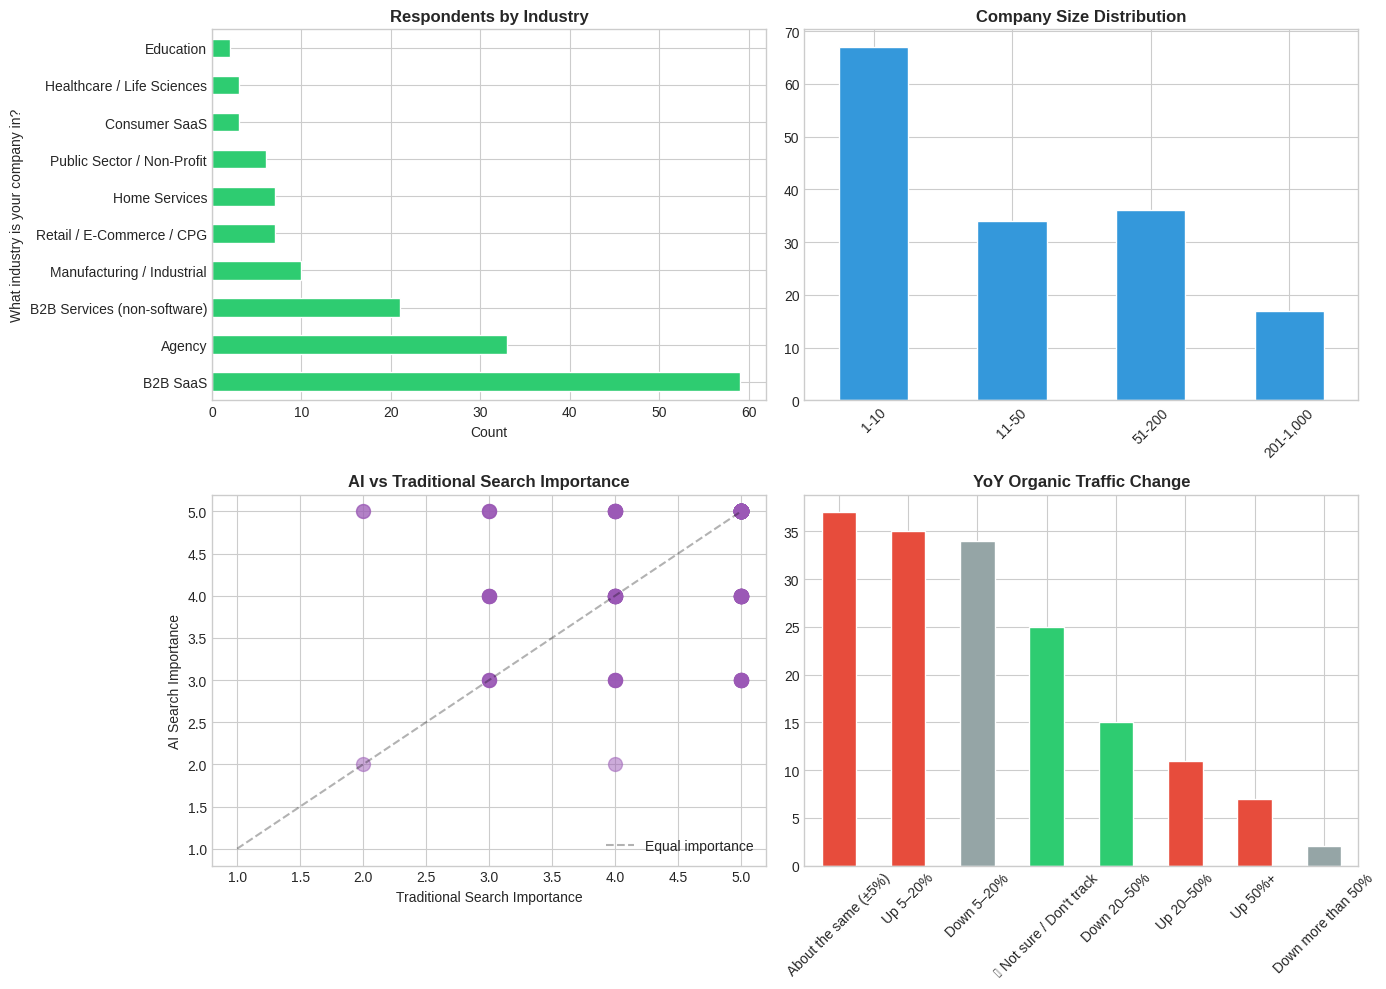

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Industry Distribution
ax1 = axes[0, 0]
industry_col = 'What industry is your company in?'
if industry_col in df.columns:
    df[industry_col].value_counts().plot(kind='barh', ax=ax1, color=colors[0])
    ax1.set_title('Respondents by Industry', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Count')

# 2. Company Size Distribution
ax2 = axes[0, 1]
size_col = 'How many employees does your company have?'
if size_col in df.columns:
    size_order = ['1-10', '11-50', '51-200', '201-1,000', '1,001-5,000', '5,000+']
    size_counts = df[size_col].value_counts().reindex([s for s in size_order if s in df[size_col].values])
    size_counts.plot(kind='bar', ax=ax2, color=colors[1])
    ax2.set_title('Company Size Distribution', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    ax2.tick_params(axis='x', rotation=45)

# 3. AI Importance vs Traditional Search Importance
ax3 = axes[1, 0]
ai_col = 'How important is it for your brand to appear in AI search/LLMs?'
trad_col = 'How important is it for your brand to maintain visibility in traditional search engines (Google, Bing, etc)?'
if ai_col in df.columns and trad_col in df.columns:
    ax3.scatter(df[trad_col], df[ai_col], alpha=0.5, c=colors[2], s=100)
    ax3.plot([1, 5], [1, 5], 'k--', alpha=0.3, label='Equal importance')
    ax3.set_xlabel('Traditional Search Importance')
    ax3.set_ylabel('AI Search Importance')
    ax3.set_title('AI vs Traditional Search Importance', fontsize=12, fontweight='bold')
    ax3.legend()

# 4. Organic Traffic Change
ax4 = axes[1, 1]
traffic_col = 'Compared to last year, your organic traffic from Google is:'
if traffic_col in df.columns:
    traffic_order = ['*🔴 Down 20–50%*', '*🔴 Down 5–20%*', '*➖ About the same (±5%)*',
                     '*🟢 Up 5–20%*', '*🟢 Up 20%+*']
    traffic_counts = df[traffic_col].value_counts()
    # Clean up the labels for display
    traffic_counts.index = traffic_counts.index.str.replace('*', '').str.replace('🔴 ', '').str.replace('🟢 ', '').str.replace('➖ ', '')
    traffic_counts.plot(kind='bar', ax=ax4, color=['#e74c3c', '#e74c3c', '#95a5a6', '#2ecc71', '#2ecc71'][:len(traffic_counts)])
    ax4.set_title('YoY Organic Traffic Change', fontsize=12, fontweight='bold')
    ax4.set_xlabel('')
    ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


In [33]:
# How mature are companies' AI strategies?
maturity_col = "How mature is your brand's strategy for AI visibility and zero-click results?"
if maturity_col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))

    maturity_counts = df[maturity_col].value_counts()
    colors_maturity = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
    maturity_counts.plot(kind='barh', ax=ax, color=colors_maturity[:len(maturity_counts)])

    ax.set_title('AI Strategy Maturity Levels', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Respondents')

    # Add percentage labels
    total = len(df[maturity_col].dropna())
    for i, (idx, val) in enumerate(maturity_counts.items()):
        ax.text(val + 0.5, i, f'{val/total*100:.0f}%', va='center')

    plt.tight_layout()
    plt.show()

    print(f"\n📊 KEY FINDING: {(maturity_counts.head(2).sum()/total*100):.0f}% of brands are still in early stages of AI search strategy")


In [34]:
# Cross-tab: Company Size vs AI Confidence
print("=== CONFIDENCE BY COMPANY SIZE ===\n")
conf_col = 'How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?'
size_col = 'How many employees does your company have?'

if conf_col in df.columns and size_col in df.columns:
    cross = pd.crosstab(df[size_col], df[conf_col], margins=True)
    print(cross)

    # Average confidence by size
    avg_conf = df.groupby(size_col)[conf_col].mean().sort_values(ascending=False)
    print("\nAverage Confidence by Company Size:")
    print(avg_conf.round(2))


=== CONFIDENCE BY COMPANY SIZE ===

How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?  1  \
How many employees does your company have?                                                          
1,000-5,000                                                                                     1   
1-10                                                                                            2   
11-50                                                                                           2   
201-1,000                                                                                       0   
5,001+                                                                                          0   
51-200                                                                                          0   
All                                                                                             5   

How confident do you feel that your brand will maintai

In [35]:
# Cross-tab: Industry vs Traffic Change
print("\n=== TRAFFIC CHANGE BY INDUSTRY ===\n")
traffic_col = 'Compared to last year, your organic traffic from Google is:'
industry_col = 'What industry is your company in?'

if traffic_col in df.columns and industry_col in df.columns:
    cross = pd.crosstab(df[industry_col], df[traffic_col], normalize='index') * 100
    cross = cross.round(1)
    print(cross)



=== TRAFFIC CHANGE BY INDUSTRY ===

Compared to last year, your organic traffic from Google is:  *❓ Not sure / Don't track*  \
What industry is your company in?                                                         
Agency                                                                              0.0   
B2B SaaS                                                                           13.6   
B2B Services (non-software)                                                        23.8   
Consumer SaaS                                                                       0.0   
Education                                                                          50.0   
Healthcare / Life Sciences                                                          0.0   
Home Services                                                                      14.3   
Manufacturing / Industrial                                                         30.0   
Public Sector / Non-Profit                           

Clustering on 4 features
Rows with complete data: 166


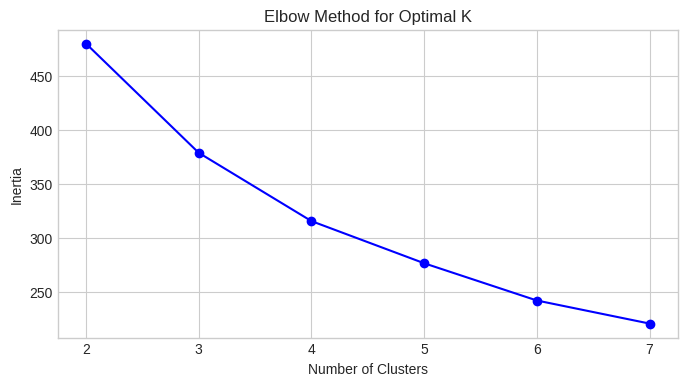

In [36]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Prepare data for clustering - use numeric columns
cluster_cols = [
    'How important is it for your brand to appear in AI search/LLMs?',
    'How important is it for your brand to maintain visibility in traditional search engines (Google, Bing, etc)?',
    'How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?',
    'How confident are you that your team can publish enough content to maintain or grow visibility across traditional search (Google) and/or AI search platforms (ChatGPT, Perplexity, etc) in 2026?'
]

# Filter to columns that exist
cluster_cols = [c for c in cluster_cols if c in df.columns]
print(f"Clustering on {len(cluster_cols)} features")

# Prepare clustering data
df_cluster = df[cluster_cols].dropna()
print(f"Rows with complete data: {len(df_cluster)}")

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# Find optimal clusters using elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


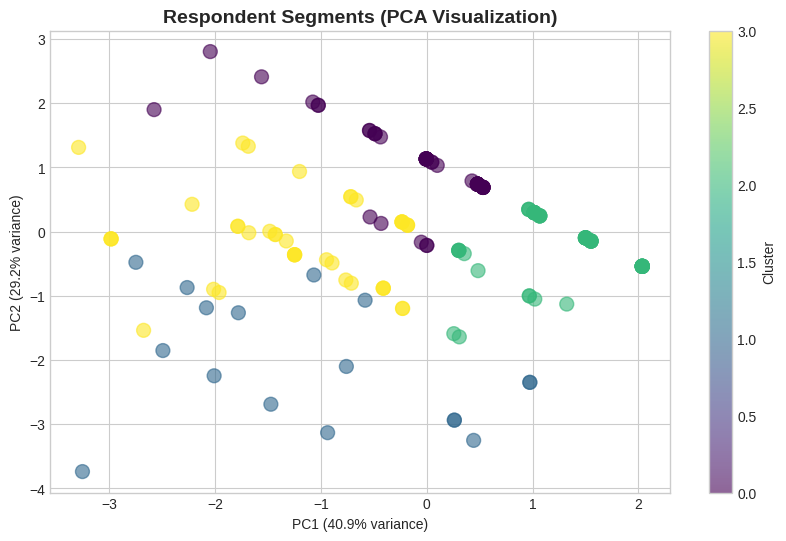


Cluster sizes:
Cluster
0    52
1    17
2    56
3    41
Name: count, dtype: int64


In [37]:
# Apply clustering with chosen K (usually 3-4 works well for surveys)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# Add cluster back to main dataframe
df.loc[df_cluster.index, 'Cluster'] = df_cluster['Cluster']

# Visualize with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster['Cluster'], cmap='viridis', alpha=0.6, s=100)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Respondent Segments (PCA Visualization)', fontsize=14, fontweight='bold')
plt.show()

print(f"\nCluster sizes:")
print(df_cluster['Cluster'].value_counts().sort_index())


In [38]:
# Profile each cluster
print("\n" + "="*60)
print("CLUSTER PROFILES")
print("="*60)

cluster_profiles = df_cluster.groupby('Cluster')[cluster_cols].mean().round(2)
print(cluster_profiles.T)

# Name the clusters based on their characteristics
print("\n📊 SEGMENT INTERPRETATION:")
for cluster_id in range(n_clusters):
    profile = cluster_profiles.loc[cluster_id]
    avg_importance = profile.iloc[0]
    avg_confidence = profile.iloc[2] if len(profile) > 2 else profile.iloc[1]

    if avg_importance >= 4 and avg_confidence >= 4:
        name = "AI Leaders"
        desc = "High importance, high confidence - ahead of the curve"
    elif avg_importance >= 4 and avg_confidence < 3:
        name = "Anxious Aspirers"
        desc = "Know AI matters but not confident they're ready - PRIME PROSPECTS"
    elif avg_importance < 3 and avg_confidence >= 3:
        name = "Traditionalists"
        desc = "Not prioritizing AI search yet"
    else:
        name = "Wait-and-See"
        desc = "Low urgency, low confidence - need education"

    print(f"\n  Cluster {cluster_id}: {name}")
    print(f"    {desc}")
    print(f"    AI Importance: {avg_importance:.1f}, Confidence: {avg_confidence:.1f}")



CLUSTER PROFILES
Cluster                                                                                                  0  \
How important is it for your brand to appear in AI search/LLMs?                                       5.00   
How important is it for your brand to maintain visibility in traditional search engines (Google, ...  4.88   
How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?        3.06   
How confident are you that your team can publish enough content to maintain or grow visibility ac...  2.98   

Cluster                                                                                                  1  \
How important is it for your brand to appear in AI search/LLMs?                                       4.00   
How important is it for your brand to maintain visibility in traditional search engines (Google, ...  2.82   
How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?       

In [42]:
import os
from getpass import getpass
from openai import OpenAI

# Get the key
api_key = getpass('Enter OpenAI API key: ')

# Create client with explicit key
client = OpenAI(api_key=api_key)

# Test it immediately
try:
    test = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": "Say 'working'"}],
        max_tokens=10
    )
    print("✓ API key working:", test.choices[0].message.content)
except Exception as e:
    print("✗ Error:", e)


Enter OpenAI API key: ··········
✓ API key working: Working.


In [44]:
# Analyze open-ended responses about fears and tactics
fear_col = 'What is your biggest fear about AI-driven search for your brand?'
tactic_col = "What's the #1 experiment or tactic you've tried (or want to try) to improve AI/AEO visibility? \n\nWhat, if any, results are you seeing from it? "

def analyze_with_ai(responses, question_context, analysis_type="themes"):
    """Use GPT-4o to analyze open-ended survey responses."""
    responses_text = "\n---\n".join([str(r) for r in responses if pd.notna(r)][:50])

    prompt = f"""You are analyzing survey responses from B2B marketing leaders about AI-driven search.

Question asked: {question_context}

Analyze these {len(responses)} responses and provide:

1. **Top 5 Themes** - Most common concerns/approaches mentioned (with % estimate)
2. **Key Quotes** - 3-4 verbatim quotes that best represent the sentiment
3. **Actionable Insights** - What should a marketing agency tell these leaders?
4. **Segment Differences** - Any patterns by sophistication level?

Responses:
{responses_text}

Format your response with clear headers and bullet points."""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )
    return response.choices[0].message.content

# Analyze fears
if fear_col in df.columns:
    print("="*60)
    print("AI ANALYSIS: BIGGEST FEARS")
    print("="*60)
    fears = df[fear_col].dropna().tolist()
    fear_analysis = analyze_with_ai(fears, fear_col)
    print(fear_analysis)


AI ANALYSIS: BIGGEST FEARS
### 1. Top 5 Themes

1. **Visibility and Competition (25%)**
   - Concerns about being overshadowed by larger competitors and maintaining visibility in a crowded market.
   
2. **Content Quality and Authenticity (20%)**
   - Fear that AI-generated content will sound robotic and not appeal to human readers, potentially damaging brand perception.
   
3. **Incorrect Information and Misrepresentation (20%)**
   - Worries about AI presenting incorrect or outdated information about the brand, leading to misrepresentation.
   
4. **Keeping Up with Rapid Changes (15%)**
   - Anxiety about the fast pace of AI developments and the challenge of staying current and competitive.
   
5. **Resource Constraints and Prioritization (10%)**
   - Concerns about limited resources and the ability to invest adequately in AI-driven search strategies.

### 2. Key Quotes

- "That our content will sound like a robot wrote it and not appeal to human readers."
- "Things feel like they're

In [45]:
# Analyze tactics
if tactic_col in df.columns:
    print("\n" + "="*60)
    print("AI ANALYSIS: TACTICS & EXPERIMENTS")
    print("="*60)
    tactics = df[tactic_col].dropna().tolist()
    tactic_analysis = analyze_with_ai(tactics, tactic_col)
    print(tactic_analysis)


In [46]:
# BONUS: Generate executive summary with AI
def generate_executive_summary(df):
    """Generate an AI-powered executive summary of the entire survey."""

    # Compile key stats
    stats = f"""
    Survey: AI-Driven Search Readiness ({len(df)} B2B marketing leaders)

    Key Metrics:
    - Average AI Search Importance: {df['How important is it for your brand to appear in AI search/LLMs?'].mean():.2f}/5
    - Average Confidence: {df['How confident do you feel that your brand will maintain visibility as AI search & LLMs evolve?'].mean():.2f}/5
    - % with emerging/no strategy: ~70%
    - Top industries: {df['What industry is your company in?'].value_counts().head(3).to_dict()}

    Traffic trends:
    {df['Compared to last year, your organic traffic from Google is:'].value_counts().to_dict()}
    """

    prompt = f"""You are a senior marketing strategist writing an executive summary for a report on "The State of AI-Driven Search in B2B Marketing."

Based on this survey data, write a compelling 3-paragraph executive summary that:
1. Opens with the key tension/finding (importance vs. confidence gap)
2. Highlights 2-3 surprising or actionable insights
3. Ends with a clear call-to-action for marketing leaders

Data:
{stats}

Write in a professional but engaging tone. Use specific numbers. Keep it under 250 words."""

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.4
    )
    return response.choices[0].message.content

print("\n" + "="*60)
print("AI-GENERATED EXECUTIVE SUMMARY")
print("="*60)
exec_summary = generate_executive_summary(df)
print(exec_summary)



AI-GENERATED EXECUTIVE SUMMARY
The recent survey on AI-driven search readiness among 166 B2B marketing leaders reveals a significant gap between the perceived importance of AI in search and the confidence in its implementation. While the average importance of AI-driven search is rated at a high 4.51 out of 5, the confidence in effectively leveraging this technology lags at 3.61. This disparity underscores a critical challenge: despite recognizing AI's potential to transform search strategies, a substantial 70% of respondents admit to having only emerging or no strategy in place.

Among the surprising insights, the survey highlights that even industries heavily reliant on digital strategies, such as B2B SaaS and agencies, report similar struggles, with no clear leader in AI adoption. Additionally, traffic trends reveal a mixed picture: while 35 respondents report a positive traffic increase of 5-20%, a close 34 experience a decline of the same magnitude, indicating that AI-driven searc